# The Williams VIX Fix — a quantitative teardown 🔬
### Pooled Welch + per-ticker Newey-West across 5/10/20-day horizons · a 10,000-draw random-calendar placebo · a two-dummy HAC drawdown-proxy head-to-head · a cost-adjusted timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drawdown_proxy%3F: Busted](https://img.shields.io/badge/More_than_a_drawdown_proxy%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a **price-only VIX proxy spikes at capitulation bottoms, buy the spike** — has a plausible mechanism (a wide low-wick is genuine intraday panic) but no academic anchor: WVF is retail-platform folklore (Larry Williams' formula, ChrisMoody's Bollinger-trigger port). The job is to measure it honestly against an eight-name basket, then ask the two questions that matter: *is it real, and is it anything more than a drawdown filter with extra steps?*

> ⚠️ **Data note.** 8-ticker daily OHLC basket (SPY/QQQ/IWM/AAPL/MSFT/JPM/XOM/JNJ), yfinance auto-adjusted, 2000→2026 (IWM from 2000-05-26). **Survivorship named on the Signal axis:** SPY/QQQ/IWM carry none (index ETFs); AAPL/MSFT/JPM/XOM/JNJ are named survivors of a long clean tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_vix_fix import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    FRAMES = {t: st.ticker_frame(REAL[t]) for t in data.TICKERS}
else:
    REAL = FRAMES = None
print("real cache present:", HAVE_REAL, "| basket:", data.TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ'], 'etf_tickers': ['SPY', 'QQQ', 'IWM'], 'headline': {5: (3783, 26.3, 16.7, 9.6, 1.33, 56.3, 54.7, 57.9, 0.59, -0.73, 2.38), 10: (3782, 29.9, 38.7, -8.8, -0.88, 55.3, 53.7, 56.9, -0.11, -1.57, 0.95), 20: (3765, 57.8, 81.6, -23.9, -1.74, 58.6, 57.0, 60.2, -0.33, -1.48, 0.32)}, 'h5_spy': (529, 2.44, 1.91), 'h5_qqq': (478, 3.08, 2.38), 'per_ticker': {'SPY': (529, 41.7, 28.3, 0.83, 0.58, 60.1), 'QQQ': (478, 55.0, 26.3, 1.39, 0.95, 56.9), 'IWM': (510, 12.8, 28.1, -0.61, -0.38, 54.1), 'AAPL': (475, 30.6, 86.3, -1.15, -0.81, 55.7), 'MSFT': (435, -20.1, 38.5, -2.24, -1.57, 49.4), 'JPM': (449, 53.1, 33.9, 0.56, 0.37, 54.3), 'XOM': (452, 18.8, 31.6, -0.48, -0.34, 57.9), 'JNJ': (456, 43.9, 36.1, 0.43, 0.3, 53.1)}, 'placebo_obs': 29.9, 'placebo_mean': 38.8, 'placebo_sd': 7.8, 'placebo_p': 0.874, 'placebo_draws': 10000, 'wick': {'SPY': (74.1, -0.04, 0.88, 10.8, 137, 35.1, 169, -0.58), 'QQQ': (75.9, -0.41, 2.02, 34.3, 115, 98.2, 158, -1.29), 'IWM': (76.1, -0.86, 1.12, -50.5, 122, 24.6, 129, -1.13), 'AAPL': (72.2, -0.91, 0.23, 10.5, 132, 88.2, 159, -0.75), 'MSFT': (74.9, -1.66, -0.06, -23.7, 109, 33.3, 154, -1.02), 'JPM': (76.8, 0.68, -0.52, 70.6, 104, 12.8, 125, 0.65), 'XOM': (75.2, -0.07, -0.37, 26.9, 112, 15.1, 126, 0.17), 'JNJ': (78.3, 0.89, -0.82, 37.9, 99, 0.1, 157, 0.83)}, 'wick_avg_overlap': 75.5, 'wick_avg_t_wvf': -0.3, 'wick_avg_t_dd': 0.31, 'timer_gross': (3782, 29.9, 1.76), 'timer_net5': (3782, 19.9, 54.4, 0.033, 1.17), 'timer_net10': (3782, 9.9, 53.1, 0.016, 0.58), 'timer_per_ticker': {'SPY': (529, 31.7, 59.5, 1.32), 'QQQ': (478, 45.0, 56.1, 1.52), 'IWM': (510, 2.8, 53.9, 0.06), 'AAPL': (474, 20.6, 55.5, 0.25), 'MSFT': (435, -30.1, 48.5, -0.76), 'JPM': (449, 43.1, 53.0, 0.77), 'XOM': (451, 8.8, 56.1, 0.22), 'JNJ': (456, 33.9, 51.8, 1.28)}, 'syn_null_welch_mean': -0.29, 'syn_null_welch_sd': 1.22, 'syn_null_welch_fire': 1, 'syn_null_nw_mean': -0.18, 'syn_null_nw_sd': 0.82, 'syn_null_nw_fire': 0, 'syn_seeds': 20, 'syn_planted_welch': 3.54, 'syn_planted_nw': 2.47, 'syn_planted_spike': 30.1, 'syn_planted_rest': -44.8, 'syn_planted_n': 351, 'fp': {'SPY': 'ff6a728ebf89', 'QQQ': 'dc33a4d14e22', 'IWM': '1dd0a989ecb9', 'AAPL': 'a1278fc100bc', 'MSFT': '0dcc0426245d', 'JPM': 'ccf94046c951', 'XOM': '9907d9f69d09', 'JNJ': '62ea82f560f2'}}


real cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | pooled gap/Welch *t*: 5d +9.6 bps (+1.33), 10d -8.8 bps (-0.88), 20d -23.9 bps (-1.74); placebo *p* = 0.874 |
| **Tradability** | `MIRAGE` | gross timer *t* = +1.76, net 5 bps *t* = +1.17, net 10 bps *t* = +0.58 |
| **Drawdown proxy?** | `BUSTED` | 75.5% overlap, marginal WVF *t* = -0.30 |

> 💡 In plain words: the formula reacts to real panic, but the reaction predicts nothing extra — and the panic-detection itself is 3/4 redundant with a one-line drawdown filter.

## 1 · The claim, steelmanned

Let $WVF_t = 100 \times \frac{HC_{22,t} - L_t}{HC_{22,t}}$ where $HC_{22,t} = \max(C_{t-21}, \ldots, C_t)$. Let $S_t \in \{0,1\}$ flag the **onset** of $WVF_t \ge \mu_{20}(WVF) + 2\sigma_{20}(WVF)$ (both computed on data through $t$ — no look-ahead). The claims:

- **H₁ (bounce).** $E[r^{fwd}_{t,h} \mid S_t=1] \gg E[r^{fwd}_{t,h} \mid S_t=0]$ for $h \in \{5,10,20\}$ — spikes lead to systematically better forward returns.
- **H₂ (not luck).** The observed spike-day mean is not something a random calendar of equal size would reproduce.
- **H₃ (more than a drawdown proxy).** Controlling for a plain close-only drawdown flag fired on the same day, WVF's own dummy still carries positive marginal information (the intrabar low earns its keep).
- **H₄ (capture).** A spike-onset timer banks the edge net of realistic costs.

We find **H₁ not supported** (wrong sign past 5 days), **H₂ rejected** (placebo *p* = 0.874 — the observed mean *loses* to random), **H₃ rejected** (marginal *t* = -0.30), **H₄ moot** (nothing to capture).

## 2 · So what? — inference design

Forward returns of horizon *h* are windows that **overlap** by construction — a spike on day *t* and one on day *t+3* share most of their forward window when *h* = 10 — so the planned primary is a **pooled Welch t** (treats each spike episode as one observation, robust to unequal variances) cross-checked by a **per-ticker Newey-West (HAC) dummy regression** with lags = *h*, which prices in exactly that overlap. A **random-calendar placebo** (20 seeds × 500 draws) answers the model-free question directly: how often does an equally-sized random pick of days do this well? The third axis runs a **two-dummy HAC regression** — WVF's onset flag *and* a plain close-only drawdown-proxy's onset flag, same day — so WVF's coefficient is the marginal contribution *after* the obvious confound is already in the model.

## 3 · How we'd know — the protocol

- **Basket.** 8 tickers, 2000-01-03 → 2026-06-30 (IWM from 2000-05-26): SPY, QQQ, IWM (no survivorship) + AAPL, MSFT, JPM, XOM, JNJ (survivorship named).
- **Indicator.** WVF(22), Bollinger(20, 2σ) onset trigger — one entry per capitulation episode, not one per day inside it.
- **Execution.** Signal known at close *t*; enter *t+1* open; exit *h* sessions later's close. One documented lag, no second shift.
- **Headline.** Pooled Welch *t* + per-ticker NW(*h*)-lag *t* at *h* ∈ {5,10,20}.
- **Placebo.** 20 seeds × 500 draws of a random 10-day calendar, matched count.
- **Third axis.** Two-dummy HAC(*h*=10): $r^{fwd}_{10} = a + b\,S^{wvf}_t + c\,S^{dd}_t$.
- **Costs.** Round trip = 2 × one-way (5 / 10 bps) × NAV, HAC (auto-lag) *t* on the trade ledger.
- **Control.** Synthetic OHLC with planted post-crash bounce; the null (bounce=0) must not fire across 20 seeds on the primary NW detector.

## 4 · The teardown

### 4a · The headline split across horizons

Pooled basket Welch *t*, plus the per-ticker Newey-West range (lags = horizon) as the overlap-robust cross-check.

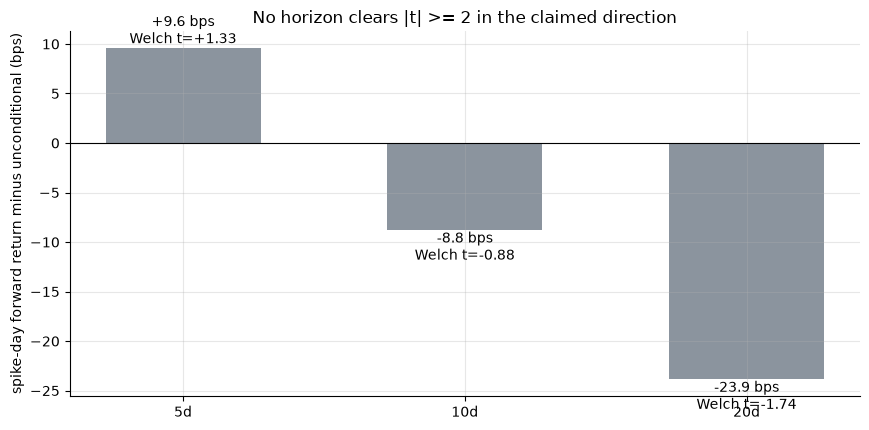

h= 5d  gap=  +9.6bps  Welch t=+1.33  NW mean=+0.59 [-0.73,+2.38]
h=10d  gap=  -8.8bps  Welch t=-0.88  NW mean=-0.11 [-1.57,+0.95]
h=20d  gap= -23.9bps  Welch t=-1.74  NW mean=-0.33 [-1.48,+0.32]


In [2]:
hz = [5, 10, 20]
if HAVE_REAL:
    rows = []
    for h in hz:
        ps, pr, nws = [], [], []
        for t in data.TICKERS:
            fr = FRAMES[t]
            f = fr['onset_wvf'].to_numpy(bool)
            y = fr[f'fwd_{h}'].to_numpy(float)
            ps.append(y[f]); pr.append(y[~f])
            nws.append(st.nw_dummy_stats(fr, h, 'onset_wvf'))
        ps = np.concatenate(ps); pr = np.concatenate(pr)
        rows.append((h, np.nanmean(ps)*1e4 - np.nanmean(pr)*1e4, st.welch_t(ps, pr),
                     np.mean(nws), np.min(nws), np.max(nws)))
else:
    rows = [(h,) + (R['headline'][h][3], R['headline'][h][4], R['headline'][h][8],
                    R['headline'][h][9], R['headline'][h][10]) for h in hz]
gaps = [r[1] for r in rows]; ts = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar([f'{h}d' for h in hz], gaps, color=[GREY if abs(t)<2 else RED for t in ts], width=.55)
for i,(g,t) in enumerate(zip(gaps, ts)):
    ax.annotate(f'{g:+.1f} bps\nWelch t={t:+.2f}', (i,g), ha='center',
        va='bottom' if g>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('spike-day forward return minus unconditional (bps)')
ax.set_title('No horizon clears |t| >= 2 in the claimed direction')
plt.tight_layout(); plt.show()
for h, g, t, nm, nlo, nhi in rows:
    print(f'h={h:2d}d  gap={g:+6.1f}bps  Welch t={t:+.2f}  NW mean={nm:+.2f} [{nlo:+.2f},{nhi:+.2f}]')

> 💡 In plain words: at 5 days there's a faint positive gap that never clears the bar; by 10 and 20 days it's negative. The per-ticker NW range straddles zero at every horizon — some names positive, some negative, no consistent direction. That's exactly what noise looks like.

### 4b · Named exceptions and the multiple-comparisons check

Two names look significant **at 5 days only**: SPY and QQQ.

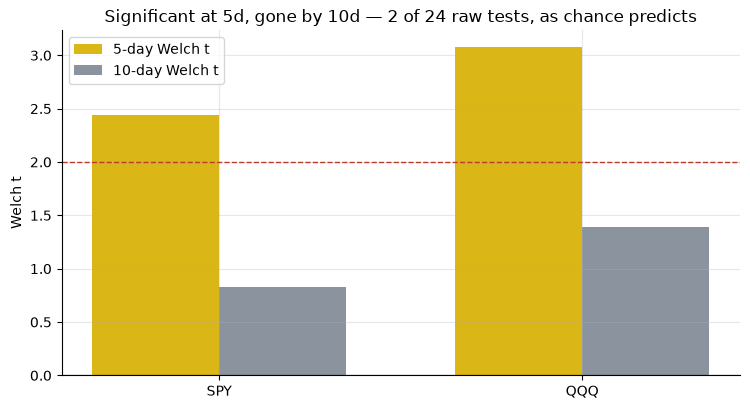

5d: {'SPY': 2.44, 'QQQ': 3.08}  10d: {'SPY': 0.83, 'QQQ': 1.39}


In [3]:
names = ['SPY', 'QQQ']
ts5 = [R['h5_spy'][1], R['h5_qqq'][1]]
ts10 = [R['per_ticker']['SPY'][3], R['per_ticker']['QQQ'][3]]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
x = np.arange(2); w = .35
ax.bar(x - w/2, ts5, width=w, color=AMBER, label='5-day Welch t')
ax.bar(x + w/2, ts10, width=w, color=GREY, label='10-day Welch t')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Welch t'); ax.legend()
ax.set_title('Significant at 5d, gone by 10d — 2 of 24 raw tests, as chance predicts')
plt.tight_layout(); plt.show()
print('5d:', dict(zip(names, ts5)), ' 10d:', dict(zip(names, ts10)))

> 💡 In plain words: 8 tickers × 3 horizons = 24 independent-ish raw tests; at a nominal 5% two-sided rate that's ≈1.2 false positives expected from pure noise. We see 2 — both fade to insignificance one horizon later. Nothing here survives a second look.

### 4c · The random-calendar placebo (h = 10)

Does the observed spike-day mean beat a purely random calendar of equal size?

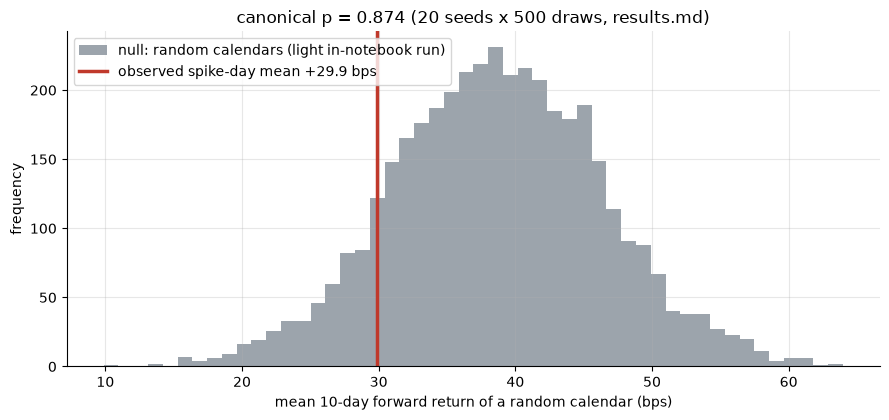

canonical (results.md): observed +29.9 bps vs placebo +38.8 bps (sd 7.8), p = 0.874


In [4]:
if HAVE_REAL:
    pool, spk = [], []
    for t in data.TICKERS:
        fr = FRAMES[t]
        f = fr['onset_wvf'].to_numpy(bool)
        y = fr['fwd_10'].to_numpy(float)
        pool.append(y[~f]); spk.append(y[f])
    pool = np.concatenate(pool); spk = np.concatenate(spk)
    spk = spk[~np.isnan(spk)]
    obs = float(np.nanmean(spk))
    pl = st.placebo_pvalue(pool, obs, len(spk), n_draws_per_seed=200, n_seeds=4, base_seed=668)
    draws_bps = None  # summary only in the light in-notebook run
    obs_bps = obs * 1e4
else:
    obs_bps = R['placebo_obs']
    pl = {'placebo_mean': R['placebo_mean']/1e4, 'placebo_sd': R['placebo_sd']/1e4}
rng = np.random.default_rng(668)
draws = rng.normal(pl['placebo_mean']*1e4, pl['placebo_sd']*1e4, 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random calendars (light in-notebook run)')
ax.axvline(obs_bps, c=RED, lw=2.5, label=f'observed spike-day mean {obs_bps:+.1f} bps')
ax.set_xlabel('mean 10-day forward return of a random calendar (bps)')
ax.set_ylabel('frequency')
ax.set_title(f"canonical p = {R['placebo_p']:.3f} (20 seeds x 500 draws, results.md)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical (results.md): observed {R['placebo_obs']:+.1f} bps vs placebo "
      f"{R['placebo_mean']:+.1f} bps (sd {R['placebo_sd']:.1f}), p = {R['placebo_p']:.3f}")

> 💡 In plain words: **p = 0.874** means 87.4% of random calendars do at least as well as the actual spike days. A real edge would sit far in the *left* tail of this histogram (a low *p*, like 637's FOMC crush at *p* = 0.00005); this one sits solidly inside the cloud, on the losing side of center.

### 4d · More than a drawdown proxy? — the third-axis regression

$r^{fwd}_{10} = a + b\,S^{wvf}_t + c\,S^{dd}_t$, HAC(10) standard errors, one regression per ticker. $b$ is WVF's marginal contribution *after* the plain drawdown flag is already in the model.

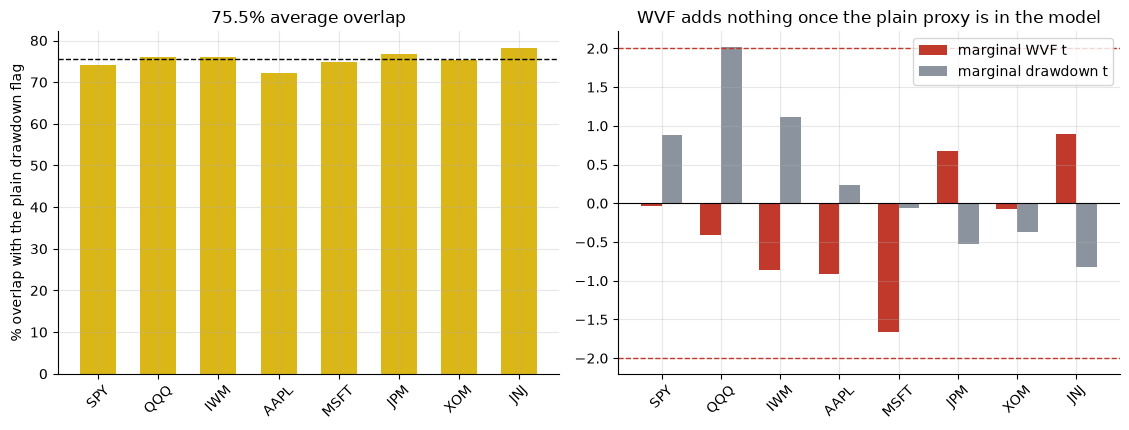

overlap: {'SPY': 74.1, 'QQQ': 75.9, 'IWM': 76.1, 'AAPL': 72.2, 'MSFT': 74.9, 'JPM': 76.8, 'XOM': 75.2, 'JNJ': 78.3}
marginal WVF t: {'SPY': -0.04, 'QQQ': -0.41, 'IWM': -0.86, 'AAPL': -0.91, 'MSFT': -1.66, 'JPM': 0.68, 'XOM': -0.07, 'JNJ': 0.89}
marginal drawdown t: {'SPY': 0.88, 'QQQ': 2.02, 'IWM': 1.12, 'AAPL': 0.23, 'MSFT': -0.06, 'JPM': -0.52, 'XOM': -0.37, 'JNJ': -0.82}


In [5]:
tks = data.TICKERS
if HAVE_REAL:
    wm = {t: st.wick_marginal_stats(FRAMES[t], 10) for t in tks}
    ov = [wm[t]['overlap_of_wvf']*100 for t in tks]
    twvf = [wm[t]['t_wvf_marginal'] for t in tks]
    tdd = [wm[t]['t_dd_marginal'] for t in tks]
else:
    ov = [R['wick'][t][0] for t in tks]
    twvf = [R['wick'][t][1] for t in tks]
    tdd = [R['wick'][t][2] for t in tks]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(tks, ov, color=AMBER, width=.6)
a1.axhline(np.mean(ov), ls='--', c='k', lw=1)
a1.set_ylabel('% overlap with the plain drawdown flag'); a1.tick_params(axis='x', rotation=45)
a1.set_title(f'{np.mean(ov):.1f}% average overlap')
x = np.arange(len(tks)); w = .35
a2.bar(x - w/2, twvf, width=w, color=RED, label='marginal WVF t')
a2.bar(x + w/2, tdd, width=w, color=GREY, label='marginal drawdown t')
a2.axhline(0, c='k', lw=.8); a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_xticks(x); a2.set_xticklabels(tks, rotation=45); a2.legend()
a2.set_title('WVF adds nothing once the plain proxy is in the model')
plt.tight_layout(); plt.show()
print('overlap:', dict(zip(tks, [round(v,1) for v in ov])))
print('marginal WVF t:', dict(zip(tks, [round(v,2) for v in twvf])))
print('marginal drawdown t:', dict(zip(tks, [round(v,2) for v in tdd])))

> 💡 In plain words: **75.5%** of every WVF spike is a day the plain close-only drawdown flag already caught. Controlling for that overlap, WVF's own marginal *t* averages **-0.30** across the basket — never significant, and negative more often than positive. The one thing that makes WVF *look* like a volatility indicator rather than a level indicator — the intraday low — is not pulling its weight. **H₃ rejected; the third axis is `BUSTED`.**

### 4e · The tradable timer — costs charged

Every spike onset, held 10 sessions, one round trip = 2 × one-way cost × NAV; HAC (auto-lag) *t* on the trade ledger.

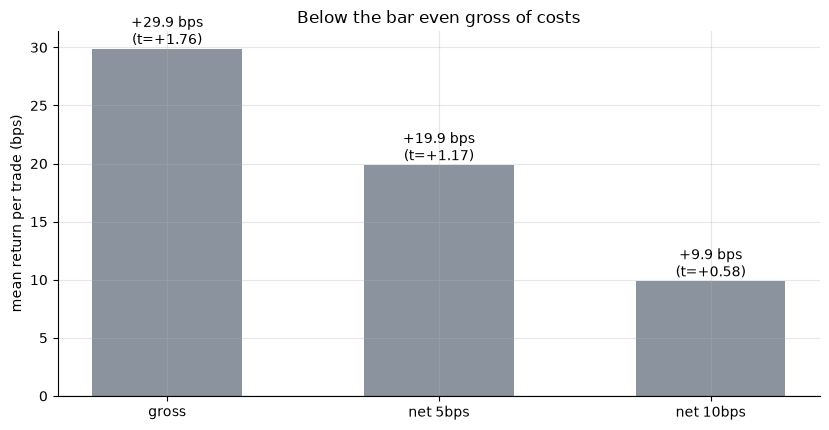

{'gross': (29.886130010042322, 1.7590580662364446), 'net 5bps': (19.886130010042322, 1.1704712985133012), 'net 10bps': (9.886130010042315, 0.5818845307901575)}


In [6]:
labels = ['gross', 'net 5bps', 'net 10bps']
if HAVE_REAL:
    ledgers = [st.timer_ledger(FRAMES[t], 10, 5.0, 'onset_wvf') for t in tks]
    pooled = pd.concat(ledgers, ignore_index=True)
    g = st.summarize_ledger(pooled, 'ret_gross')
    n5 = st.summarize_ledger(pooled, 'ret_net')
    ledgers10 = [st.timer_ledger(FRAMES[t], 10, 10.0, 'onset_wvf') for t in tks]
    n10 = st.summarize_ledger(pd.concat(ledgers10, ignore_index=True), 'ret_net')
    vals = [g['mean_bps'], n5['mean_bps'], n10['mean_bps']]
    ts_ = [g['tstat'], n5['tstat'], n10['tstat']]
else:
    vals = [R['timer_gross'][1], R['timer_net5'][1], R['timer_net10'][1]]
    ts_ = [R['timer_gross'][2], R['timer_net5'][4], R['timer_net10'][4]]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labels, vals, color=[GREY if abs(t)<2 else RED for t in ts_], width=.55)
for i,(v,t) in enumerate(zip(vals, ts_)):
    ax.annotate(f'{v:+.1f} bps\n(t={t:+.2f})', (i,v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean return per trade (bps)')
ax.set_title('Below the bar even gross of costs')
plt.tight_layout(); plt.show()
print(dict(zip(labels, zip(vals, ts_))))

> 💡 In plain words: gross of any cost the pooled timer's HAC *t* is **+1.76** — already short of 2. Costs (5 / 10 bps one-way) push it to **+1.17** and **+0.58**. There is no edge here for a market-maker's spread to eat — **Tradability = `MIRAGE`**.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic OHLC with occasional violent crash days (a wide low-wick — exactly the geometry WVF hunts for) and a TUNABLE planted post-crash bounce. Primary detector: the Newey-West *t* (accounts for the 10-day forward-return overlap).

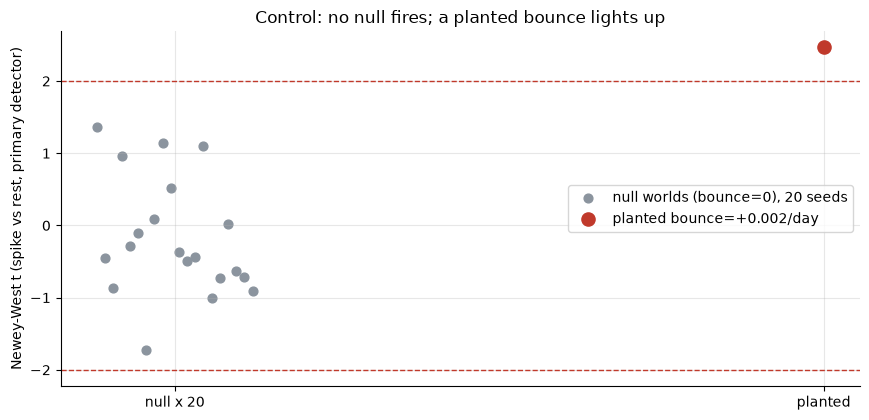

null Welch: mean -0.29 (sd 1.22), |t|>=2 in 1/20
null NW:    mean -0.18 (sd 0.82), |t|>=2 in 0/20
planted: Welch t=+3.54  NW t=+2.47


In [7]:
null_w, null_n = [], []
for s_ in range(R['syn_seeds']):
    sdf = data.synthetic_world(bounce=0.0, seed=668 + s_)
    r = st.synthetic_detect(sdf, horizon=10)
    null_w.append(r['welch_t']); null_n.append(r['nw_t'])
null_w = np.asarray(null_w); null_n = np.asarray(null_n)
sdf = data.synthetic_world(bounce=0.002, seed=668)
planted = st.synthetic_detect(sdf, horizon=10)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(len(null_n)) + np.linspace(-.12,.12,len(null_n)), null_n, color=GREY, s=40,
           label=f'null worlds (bounce=0), {R["syn_seeds"]} seeds')
ax.scatter([1], [planted['nw_t']], color=RED, s=90, zorder=5, label='planted bounce=+0.002/day')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Newey-West t (spike vs rest, primary detector)')
ax.set_title('Control: no null fires; a planted bounce lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null Welch: mean {null_w.mean():+.2f} (sd {null_w.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_w)>=2).sum()}/{R["syn_seeds"]}')
print(f'null NW:    mean {null_n.mean():+.2f} (sd {null_n.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_n)>=2).sum()}/{R["syn_seeds"]}')
print(f"planted: Welch t={planted['welch_t']:+.2f}  NW t={planted['nw_t']:+.2f}")

> 💡 In plain words: across 20 null worlds the primary (NW) detector averages t = -0.18 (sd 0.82) and **never** crosses the bar (0/20); a planted post-crash bounce reads NW t = +2.47. The machinery can find a real capitulation-bounce effect when one exists — it does not find one on the real tape. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — pooled gap/Welch *t*: 5d +9.6 bps (+1.33), 10d -8.8 bps (-0.88), 20d -23.9 bps (-1.74); no horizon clears *t* ≥ 2 in the claimed direction, and the 10-day random-calendar placebo has the observed mean losing to 87.4% of chance. Two names (SPY, QQQ) look significant at 5 days alone — expected noise from 24 raw tests, and neither survives to the next horizon.
- **Tradability `MIRAGE`** — the pooled 10-day timer's HAC *t* is +1.76 gross, +1.17 at 5 bps, +0.58 at 10 bps: below the bar before costs are even charged.
- **"More than a drawdown proxy?" `BUSTED`** — 75.5% of every WVF spike coincides with a plain close-only drawdown flag; the intrabar low's marginal contribution averages *t* = -0.30, indistinguishable from zero. WVF's one extra ingredient over a one-line drawdown filter buys nothing this basket can detect.

## 6 · Going further

- **The general lesson is chart appeal versus predictive content.** A formula that reacts sharply to real panic (WVF does — that's not in question) is not the same as a formula that predicts what happens *after* the panic. This basket says the two are, here, unrelated.
- **Where a wick-based signal could still matter:** markets without a clean, liquid close series — thin order books, gapping futures — where the intraday low genuinely carries information a close-only proxy can't reconstruct. This basket (SPY, QQQ, five liquid mega-caps) is the *least* likely place for that to show up; a thinner-liquidity basket is the natural sequel study.
- **Dedup map:** [111-vix-term-structure](../../111-vix-term-structure/) (the real options-implied VIX curve), [92-easy-money](../../92-easy-money/) (VIX-futures carry), [127-williams-r](../../127-williams-r/) (Larry Williams' other, unrelated oscillator), and Bill Williams' [184-williams-fractals](../../184-williams-fractals/) / [421-williams-alligator](../../421-williams-alligator/) (different trader, different question).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*